In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
data = {
    "Time": [20,25,30,35,40,45,50,55,28,32,38,42,48,52,60,27,33,37,44,58],
    "Distance": [2,3,4,5,6,7,8,9,3,4,5,6,7,8,10,2,4,5,6,9],
    "Weather": [0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,0,0,1,1,1],
    "OnTime": [1,1,1,1,1,0,0,0,1,1,1,1,0,0,0,1,1,1,1,0]
}

df = pd.DataFrame(data)

print(df)

    Time  Distance  Weather  OnTime
0     20         2        0       1
1     25         3        0       1
2     30         4        0       1
3     35         5        1       1
4     40         6        1       1
5     45         7        1       0
6     50         8        1       0
7     55         9        1       0
8     28         3        0       1
9     32         4        0       1
10    38         5        1       1
11    42         6        1       1
12    48         7        1       0
13    52         8        1       0
14    60        10        1       0
15    27         2        0       1
16    33         4        0       1
17    37         5        1       1
18    44         6        1       1
19    58         9        1       0


In [3]:
df = pd.read_csv("/random_stock_market_dataset.csv")

print(df.head())

         Date    Open    High     Low   Close  Volume
0  2024-01-01  296.45  307.31  293.96  303.72   93133
1  2024-01-02  190.11  193.10  187.21  191.40   64993
2  2024-01-03  197.41  208.64  193.37  205.89   70326
3  2024-01-04  253.13  262.67  248.67  258.95   17358
4  2024-01-05  241.35  253.09  238.99  252.20   20847


In [4]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(60, 6)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [6]:
df['Movement'] = (df['Close'] > df['Open']).astype(int)
X = df[["Open", "High", "Low", "Close", "Volume"]]
y = df["Movement"]

print(X.head())
print(y.head())

     Open    High     Low   Close  Volume
0  296.45  307.31  293.96  303.72   93133
1  190.11  193.10  187.21  191.40   64993
2  197.41  208.64  193.37  205.89   70326
3  253.13  262.67  248.67  258.95   17358
4  241.35  253.09  238.99  252.20   20847
0    1
1    1
2    1
3    1
4    1
Name: Movement, dtype: int64


In [7]:
df["Movement"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

df = df.dropna()

X = df[["Open", "High", "Low", "Close", "Volume"]]
y = df["Movement"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (48, 5)
Testing data: (12, 5)


In [9]:
model = GaussianNB()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [10]:
y_pred = model.predict(X_test)

print("Actual:")
print(y_test.values)

print("Predicted:")
print(y_pred)

Actual:
[0 0 0 0 0 0 1 0 1 0 0 1]
Predicted:
[1 0 0 0 0 0 1 0 1 0 0 1]


In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9166666666666666
Precision: 0.75
Recall: 1.0
F1 Score: 0.8571428571428571


Confusion Matrix:
[[8 1]
 [0 3]]


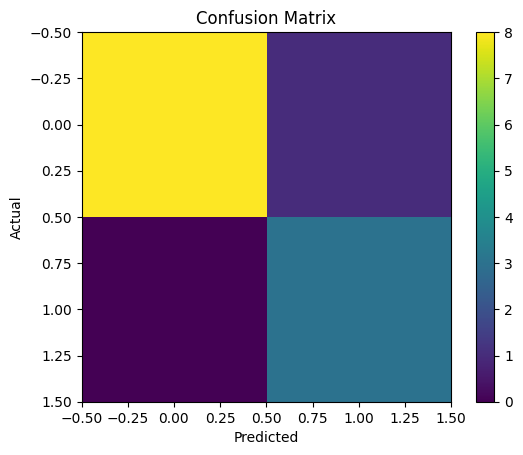

In [12]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

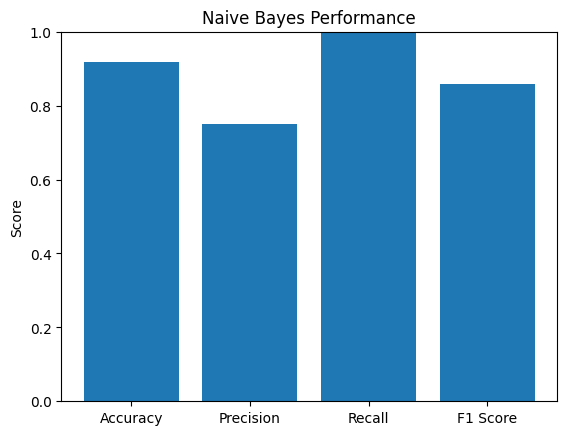

In [13]:
names = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [accuracy, precision, recall, f1]

plt.bar(names, values)
plt.ylim(0, 1)
plt.title("Naive Bayes Performance")
plt.ylabel("Score")
plt.show()

In [14]:
new_stock = [[100, 105, 98, 103, 500000]]

result = model.predict(new_stock)

if result[0] == 1:
    print("Prediction: Stock Price will go UP")
else:
    print("Prediction: Stock Price will go DOWN")

Prediction: Stock Price will go UP


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


**INTERPRETATION**

The Naive Bayes classification model was used to predict whether the stock price would increase or decrease based on features such as Open, High, Low, Close, and Volume. The dataset was divided into training and testing data, and the model was trained using the Gaussian Naive Bayes algorithm. The predicted results were compared with the actual stock movements using accuracy, precision, recall, and F1-score. The confusion matrix shows the number of correctly and incorrectly classified stock movements. Finally, the trained model was used to predict the movement of a new unseen stock sample. Overall, the experiment demonstrates how Naive Bayes can be applied to stock movement classification.